# Customer Segmentation and Predictive Analytics Using Machine Learning (R)

## 1. Install and Load Libraries

In [1]:
options(repos = c(CRAN = "https://cloud.r-project.org"))
options(timeout = 600)

system("apt-get install -y -qq pandoc > /dev/null 2>&1")

pkgs <- c("readxl", "dplyr", "tidyr", "ggplot2", "lubridate", "cluster",
          "randomForest", "e1071", "pROC", "plotly", "htmlwidgets", "reshape2")
new_pkgs <- pkgs[!(pkgs %in% installed.packages()[, "Package"])]
if (length(new_pkgs) > 0) install.packages(new_pkgs)

invisible(lapply(pkgs, library, character.only = TRUE))

options(repr.plot.width = 11, repr.plot.height = 6)
SEED <- 42
set.seed(SEED)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘lazyeval’, ‘proxy’, ‘crosstalk’, ‘plyr’



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin


The following object is masked from ‘package:dplyr’:

    combine



Attaching package: ‘e1071’


The following object is masked from ‘package:ggplot2’:

    element


Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var



Attaching pa

## 2. Load Dataset from UCI Link

In [2]:
url <- "https://archive.ics.uci.edu/static/public/352/online+retail.zip"
zip_path <- tempfile(fileext = ".zip")

download.file(url, zip_path, mode = "wb", quiet = TRUE, method = "libcurl",
              headers = c("User-Agent" = "Mozilla/5.0"))

extracted <- unzip(zip_path, exdir = tempdir())
xlsx_path <- extracted[grepl("\\.xlsx$", extracted, ignore.case = TRUE)][1]

df <- read_excel(
  xlsx_path,
  col_types = c("text", "text", "text", "numeric", "date", "numeric", "numeric", "text")
)

print(dim(df))
head(df)

[1] 541909      8


InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
<chr>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<chr>
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom


## 3. Dataset Description

In [3]:
str(df)
print(summary(df))
print(colSums(is.na(df)))
cat("Duplicates:", sum(duplicated(df)), "\n")
cat("Cancellations:", sum(startsWith(df$InvoiceNo, "C"), na.rm = TRUE), "\n")
cat("Countries:", n_distinct(df$Country), "\n")

tibble [541,909 × 8] (S3: tbl_df/tbl/data.frame)
 $ InvoiceNo  : chr [1:541909] "536365" "536365" "536365" "536365" ...
 $ StockCode  : chr [1:541909] "85123A" "71053" "84406B" "84029G" ...
 $ Description: chr [1:541909] "WHITE HANGING HEART T-LIGHT HOLDER" "WHITE METAL LANTERN" "CREAM CUPID HEARTS COAT HANGER" "KNITTED UNION FLAG HOT WATER BOTTLE" ...
 $ Quantity   : num [1:541909] 6 6 8 6 6 2 6 6 6 32 ...
 $ InvoiceDate: POSIXct[1:541909], format: "2010-12-01 08:26:00" "2010-12-01 08:26:00" ...
 $ UnitPrice  : num [1:541909] 2.55 3.39 2.75 3.39 3.39 7.65 4.25 1.85 1.85 1.69 ...
 $ CustomerID : num [1:541909] 17850 17850 17850 17850 17850 ...
 $ Country    : chr [1:541909] "United Kingdom" "United Kingdom" "United Kingdom" "United Kingdom" ...
     InvoiceNo          StockCode         Description        Quantity         
 Length   :541909   Length   :541909   Length   :541909   Min.   :-80995.000  
 N.unique : 25900   N.unique :  4070   N.unique :  4211   1st Qu.:     1.000  
 N.blank

## 4. Data Cleaning

In [4]:
data <- df
n_start <- nrow(data)

data <- data %>% filter(!is.na(CustomerID))
cat("Missing CustomerID removed:", n_start - nrow(data), "\n")

n_prev <- nrow(data)
data <- data %>% filter(!startsWith(InvoiceNo, "C"))
cat("Cancellations removed:", n_prev - nrow(data), "\n")

n_prev <- nrow(data)
data <- data %>% filter(Quantity > 0, UnitPrice > 0)
cat("Invalid quantity/price removed:", n_prev - nrow(data), "\n")

n_prev <- nrow(data)
data <- data %>% distinct()
cat("Duplicates removed:", n_prev - nrow(data), "\n")

data <- data %>%
  mutate(CustomerID = as.integer(CustomerID),
         TotalPrice = Quantity * UnitPrice)

print(dim(data))
head(data)

Missing CustomerID removed: 135080 
Cancellations removed: 8905 
Invalid quantity/price removed: 40 
Duplicates removed: 5192 
[1] 392692      9


InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
<chr>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<int>,<chr>,<dbl>
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom,15.30


## 5. Customer-Level Feature Engineering (RFM and Behavioural Features)

In [5]:
snapshot_date <- max(data$InvoiceDate) + days(1)

customer <- data %>%
  group_by(CustomerID) %>%
  summarise(
    Recency = floor(as.numeric(difftime(snapshot_date, max(InvoiceDate), units = "days"))),
    Frequency = n_distinct(InvoiceNo),
    Monetary = sum(TotalPrice),
    TotalQuantity = sum(Quantity),
    UniqueProducts = n_distinct(StockCode),
    FirstPurchase = min(InvoiceDate),
    LastPurchase = max(InvoiceDate),
    .groups = "drop"
  ) %>%
  mutate(
    AvgTransactionValue = Monetary / Frequency,
    AvgBasketQuantity = TotalQuantity / Frequency,
    ActiveMonths = pmax(as.numeric(difftime(LastPurchase, FirstPurchase, units = "days")) / 30, 1),
    PurchaseFrequency = Frequency / ActiveMonths
  ) %>%
  dplyr::select(-FirstPurchase, -LastPurchase, -ActiveMonths) %>%
  as.data.frame()

features <- c("Recency", "Frequency", "Monetary", "AvgTransactionValue",
              "TotalQuantity", "PurchaseFrequency", "UniqueProducts", "AvgBasketQuantity")

print(dim(customer))
head(customer)

[1] 4338    9


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,AvgTransactionValue,AvgBasketQuantity,PurchaseFrequency
,<int>,<dbl>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
1,12346,326,1,77183.60,74215,1,77183.6000,74215.0000,1.0000000
2,12347,2,7,4310.00,2458,103,615.7143,351.1429,0.5752823
3,12348,75,4,1797.24,2341,22,449.3100,585.2500,0.4243990
4,12349,19,1,1757.55,631,73,1757.5500,631.0000,1.0000000
5,12350,310,1,334.40,197,17,334.4000,197.0000,1.0000000
6,12352,36,8,2506.04,536,59,313.2550,67.0000,0.9227713


## 6. Feature Distribution Before Treatment

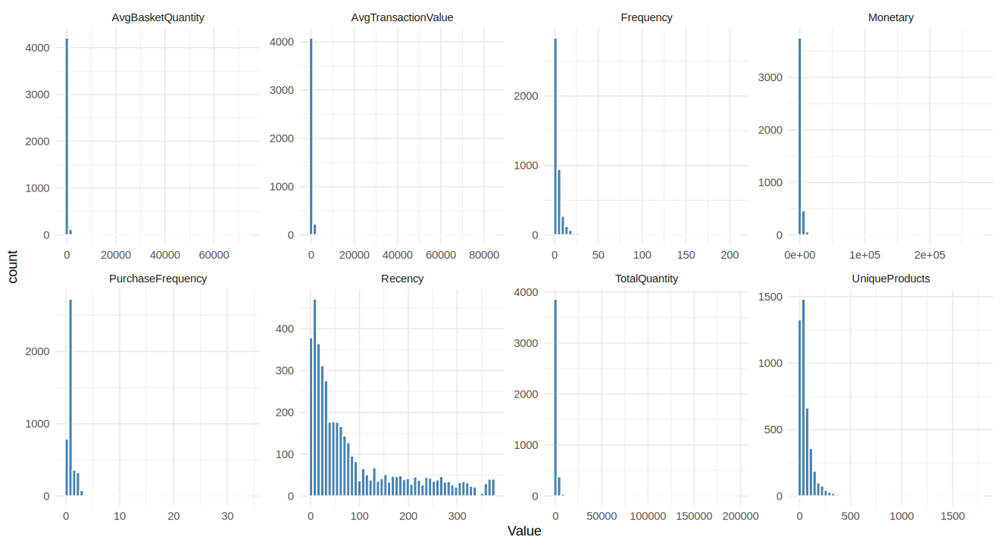

In [6]:
customer %>%
  dplyr::select(all_of(features)) %>%
  pivot_longer(everything(), names_to = "Feature", values_to = "Value") %>%
  ggplot(aes(x = Value)) +
  geom_histogram(bins = 50, fill = "steelblue", color = "white") +
  facet_wrap(~Feature, scales = "free", ncol = 4) +
  theme_minimal()

## 7. Outlier Treatment (Log Transform and IQR Capping)

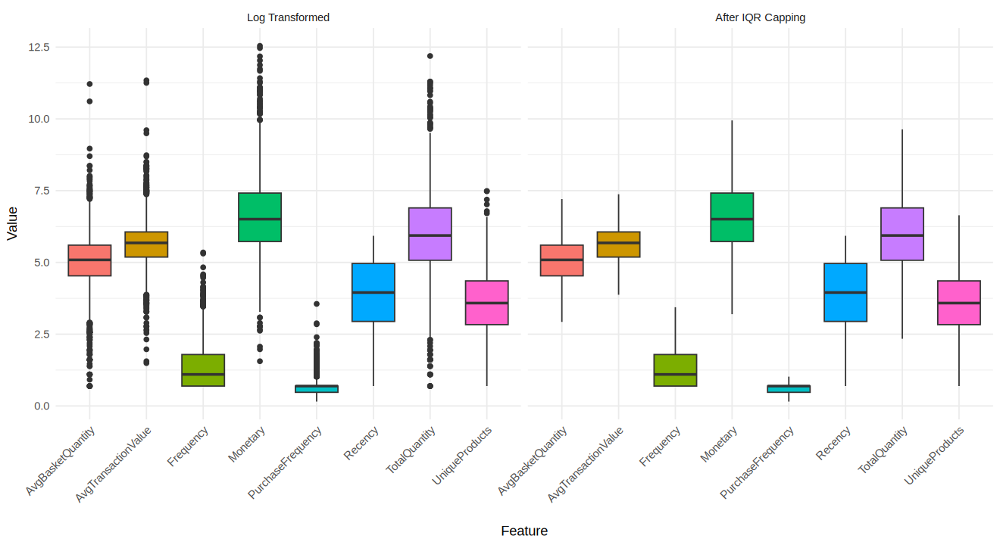

In [7]:
cap_iqr <- function(x) {
  q <- quantile(x, c(0.25, 0.75))
  iqr <- q[2] - q[1]
  pmin(pmax(x, q[1] - 1.5 * iqr), q[2] + 1.5 * iqr)
}

customer_log <- as.data.frame(lapply(customer[features], log1p))
customer_treated <- as.data.frame(lapply(customer_log, cap_iqr))

stage_levels <- c("Log Transformed", "After IQR Capping")

long_before <- pivot_longer(customer_log, everything(), names_to = "Feature", values_to = "Value") %>%
  mutate(Stage = "Log Transformed")
long_after <- pivot_longer(customer_treated, everything(), names_to = "Feature", values_to = "Value") %>%
  mutate(Stage = "After IQR Capping")

rbind(long_before, long_after) %>%
  mutate(Stage = factor(Stage, levels = stage_levels)) %>%
  ggplot(aes(x = Feature, y = Value, fill = Feature)) +
  geom_boxplot(show.legend = FALSE) +
  facet_wrap(~Stage) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

## 8. Feature Scaling

In [8]:
cluster_features <- c("Recency", "Frequency", "Monetary", "AvgTransactionValue",
                      "TotalQuantity", "PurchaseFrequency")

X_scaled <- scale(as.matrix(customer_treated[cluster_features]))

print(round(colMeans(X_scaled), 2))
print(round(apply(X_scaled, 2, sd), 2))

            Recency           Frequency            Monetary AvgTransactionValue 
                  0                   0                   0                   0 
      TotalQuantity   PurchaseFrequency 
                  0                   0 
            Recency           Frequency            Monetary AvgTransactionValue 
                  1                   1                   1                   1 
      TotalQuantity   PurchaseFrequency 
                  1                   1 


## 9. Correlation Heatmap

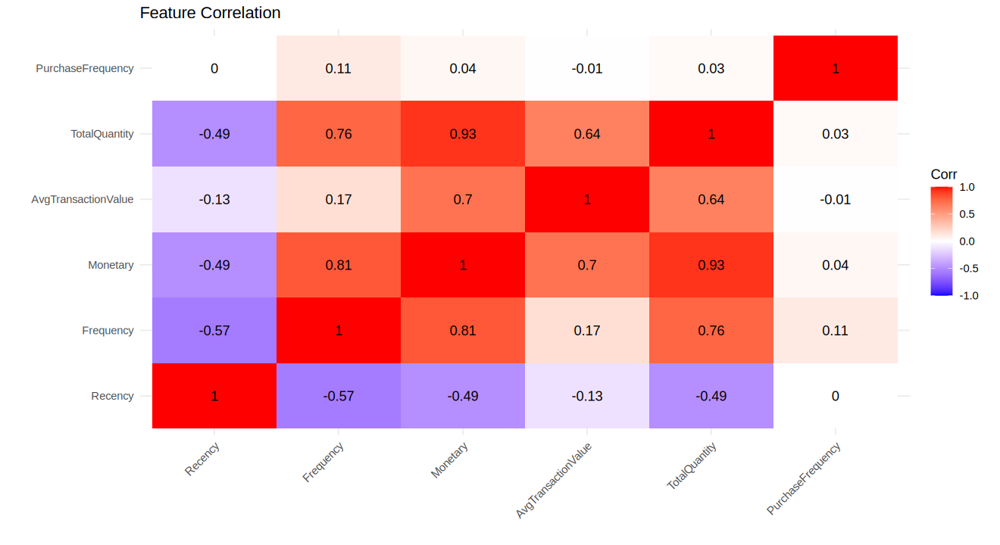

In [9]:
cor_long <- melt(cor(customer_treated[cluster_features]))

ggplot(cor_long, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile() +
  geom_text(aes(label = round(value, 2))) +
  scale_fill_gradient2(low = "blue", mid = "white", high = "red", limits = c(-1, 1)) +
  labs(title = "Feature Correlation", x = NULL, y = NULL, fill = "Corr") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

## 10. Elbow Method

Optimal k: 4 


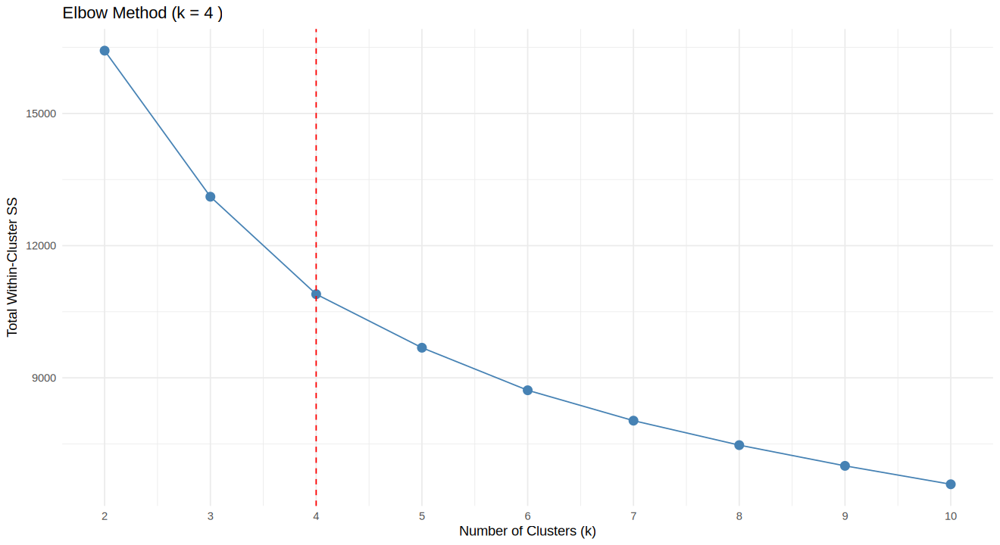

In [10]:
k_range <- 2:10

set.seed(SEED)
inertias <- sapply(k_range, function(k) {
  kmeans(X_scaled, centers = k, nstart = 10, iter.max = 100)$tot.withinss
})

x <- as.numeric(k_range)
y <- inertias
x_n <- (x - min(x)) / (max(x) - min(x))
y_n <- (y - min(y)) / (max(y) - min(y))
line_vec <- c(x_n[length(x_n)] - x_n[1], y_n[length(y_n)] - y_n[1])
line_vec <- line_vec / sqrt(sum(line_vec^2))
pts <- cbind(x_n - x_n[1], y_n - y_n[1])
proj <- as.vector(pts %*% line_vec)
resid <- pts - outer(proj, line_vec)
dist_to_line <- sqrt(rowSums(resid^2))
OPTIMAL_K <- x[which.max(dist_to_line)]

ggplot(data.frame(k = k_range, Inertia = inertias), aes(x = k, y = Inertia)) +
  geom_line(color = "steelblue") +
  geom_point(size = 3, color = "steelblue") +
  geom_vline(xintercept = OPTIMAL_K, color = "red", linetype = "dashed") +
  scale_x_continuous(breaks = k_range) +
  labs(title = paste("Elbow Method (k =", OPTIMAL_K, ")"),
       x = "Number of Clusters (k)", y = "Total Within-Cluster SS") +
  theme_minimal()

cat("Optimal k:", OPTIMAL_K, "\n")

## 11. Silhouette Score for Different k

   k   Inertia Silhouette
1  2 16425.428     0.3213
2  3 13110.496     0.2739
3  4 10898.438     0.2672
4  5  9683.454     0.2528
5  6  8717.863     0.2632
6  7  8028.166     0.2559
7  8  7472.820     0.2395
8  9  7002.711     0.2405
9 10  6584.751     0.2356


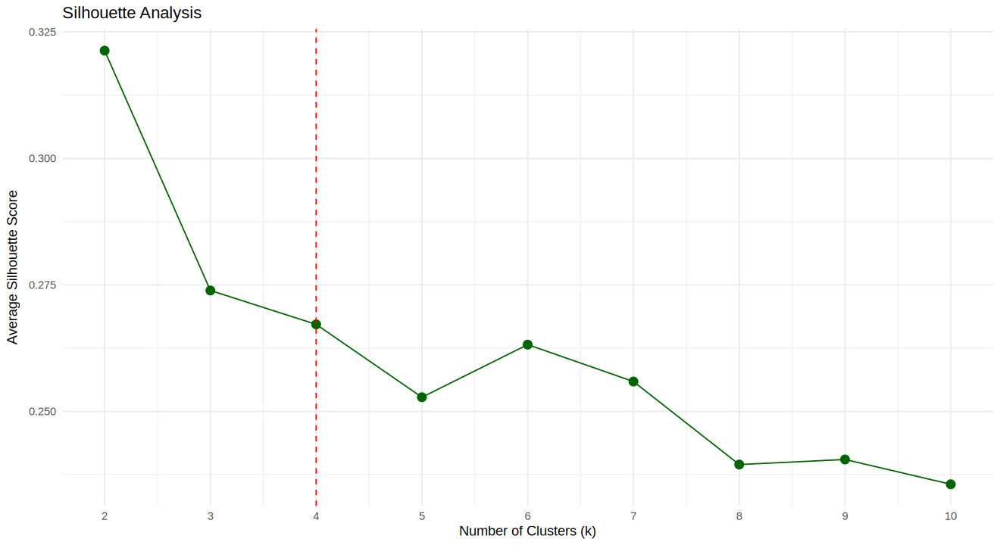

In [11]:
dist_mat <- dist(X_scaled)

set.seed(SEED)
sil_scores <- sapply(k_range, function(k) {
  km <- kmeans(X_scaled, centers = k, nstart = 10, iter.max = 100)
  mean(silhouette(km$cluster, dist_mat)[, 3])
})

sil_table <- data.frame(k = k_range, Inertia = inertias, Silhouette = round(sil_scores, 4))

ggplot(sil_table, aes(x = k, y = Silhouette)) +
  geom_line(color = "darkgreen") +
  geom_point(size = 3, color = "darkgreen") +
  geom_vline(xintercept = OPTIMAL_K, color = "red", linetype = "dashed") +
  scale_x_continuous(breaks = k_range) +
  labs(title = "Silhouette Analysis", x = "Number of Clusters (k)", y = "Average Silhouette Score") +
  theme_minimal()

print(sil_table)

## 12. K-Means Clustering

In [12]:
set.seed(SEED)
km_model <- kmeans(X_scaled, centers = OPTIMAL_K, nstart = 25, iter.max = 100)
customer$KMeans_Cluster <- km_model$cluster

kmeans_silhouette <- mean(silhouette(customer$KMeans_Cluster, dist_mat)[, 3])

cat("K-Means Silhouette Score:", round(kmeans_silhouette, 4), "\n")
print(table(customer$KMeans_Cluster))

K-Means Silhouette Score: 0.2672 

   1    2    3    4 
1061 1165  790 1322 


## 13. Hierarchical Clustering and Dendrogram

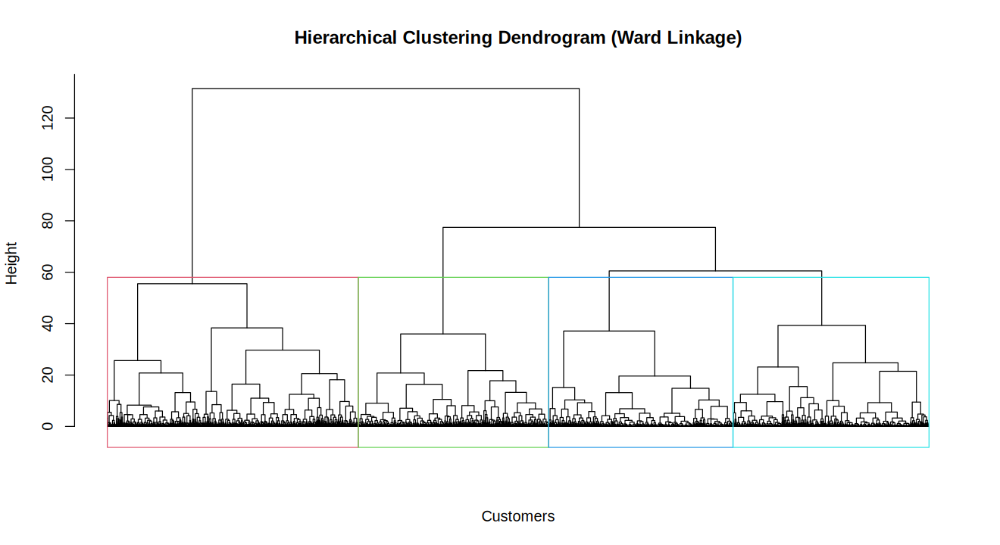

In [13]:
hc <- hclust(dist_mat, method = "ward.D2")

plot(hc, labels = FALSE, hang = -1, xlab = "Customers", sub = "",
     main = "Hierarchical Clustering Dendrogram (Ward Linkage)")
rect.hclust(hc, k = OPTIMAL_K, border = 2:(OPTIMAL_K + 1))

## 14. Hierarchical Cluster Assignment and Comparison with K-Means

               Method Silhouette
1             K-Means     0.2672
2 Hierarchical (Ward)     0.2123
Adjusted Rand Index (K-Means vs Hierarchical): 0.5141 
      Hierarchical
KMeans   1   2   3   4
     1   0  35 868 158
     2  93 908 127  37
     3 767  14   0   9
     4 465  16  40 801


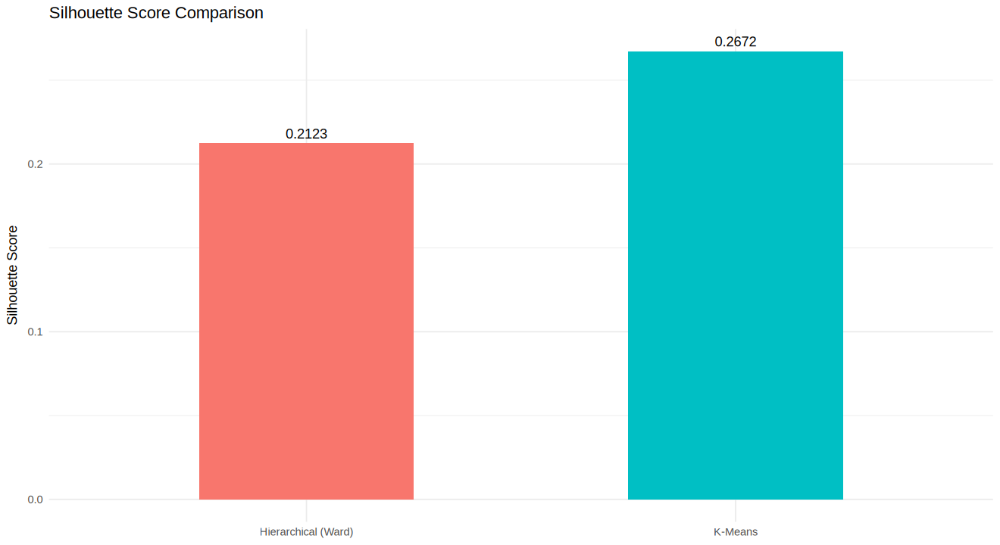

In [14]:
adjusted_rand <- function(a, b) {
  tab <- table(a, b)
  n <- sum(tab)
  sum_comb <- function(v) sum(choose(v, 2))
  idx <- sum_comb(tab)
  ra <- sum_comb(rowSums(tab))
  cb <- sum_comb(colSums(tab))
  expected <- ra * cb / choose(n, 2)
  (idx - expected) / (0.5 * (ra + cb) - expected)
}

customer$Hierarchical_Cluster <- cutree(hc, k = OPTIMAL_K)

hier_silhouette <- mean(silhouette(customer$Hierarchical_Cluster, dist_mat)[, 3])
ari <- adjusted_rand(customer$KMeans_Cluster, customer$Hierarchical_Cluster)

comparison <- data.frame(
  Method = c("K-Means", "Hierarchical (Ward)"),
  Silhouette = round(c(kmeans_silhouette, hier_silhouette), 4)
)

print(comparison)
cat("Adjusted Rand Index (K-Means vs Hierarchical):", round(ari, 4), "\n")
print(table(KMeans = customer$KMeans_Cluster, Hierarchical = customer$Hierarchical_Cluster))

ggplot(comparison, aes(x = Method, y = Silhouette, fill = Method)) +
  geom_col(show.legend = FALSE, width = 0.5) +
  geom_text(aes(label = Silhouette), vjust = -0.5) +
  labs(title = "Silhouette Score Comparison", y = "Silhouette Score", x = NULL) +
  theme_minimal()

## 15. PCA 2D Visualization of Customer Segments

Explained variance (PC1, PC2): 0.562 0.1771 
Total variance explained: 0.7391 


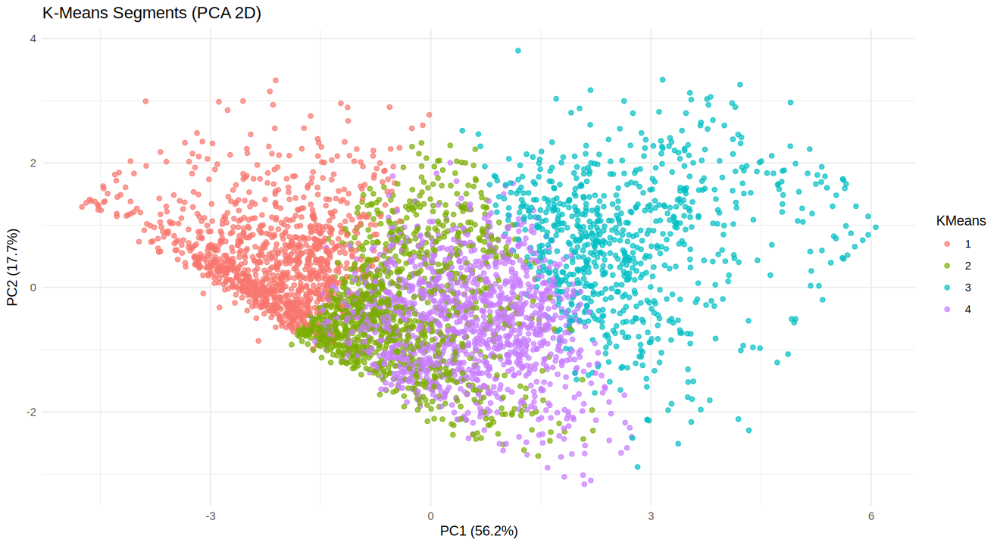

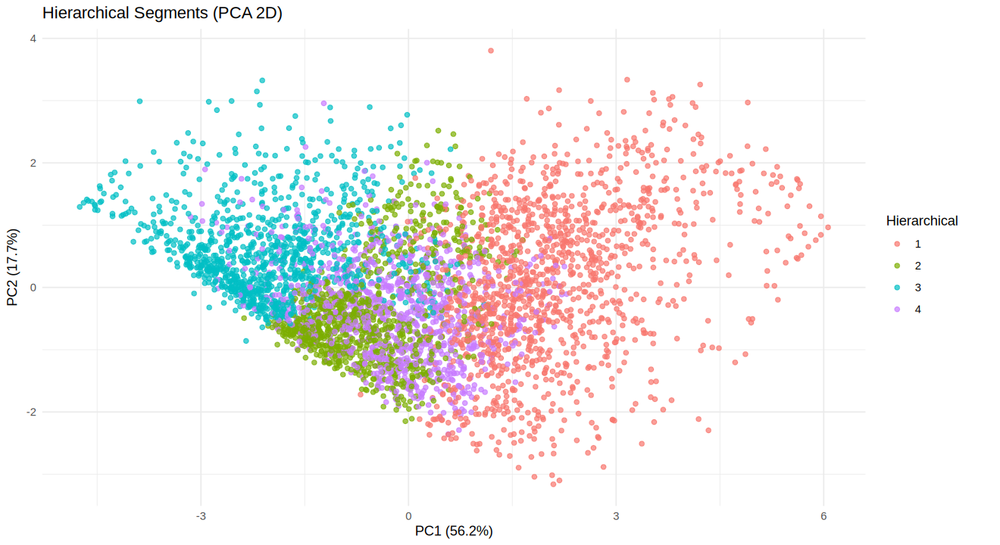

In [15]:
pca_full <- prcomp(X_scaled, center = FALSE, scale. = FALSE)
var_ratio <- pca_full$sdev^2 / sum(pca_full$sdev^2)

pca_df <- data.frame(
  PC1 = pca_full$x[, 1],
  PC2 = pca_full$x[, 2],
  KMeans = factor(customer$KMeans_Cluster),
  Hierarchical = factor(customer$Hierarchical_Cluster)
)

cat("Explained variance (PC1, PC2):", round(var_ratio[1:2], 4), "\n")
cat("Total variance explained:", round(sum(var_ratio[1:2]), 4), "\n")

p_km <- ggplot(pca_df, aes(x = PC1, y = PC2, color = KMeans)) +
  geom_point(alpha = 0.7, size = 1.5) +
  labs(title = "K-Means Segments (PCA 2D)",
       x = paste0("PC1 (", round(var_ratio[1] * 100, 1), "%)"),
       y = paste0("PC2 (", round(var_ratio[2] * 100, 1), "%)")) +
  theme_minimal()

p_hc <- ggplot(pca_df, aes(x = PC1, y = PC2, color = Hierarchical)) +
  geom_point(alpha = 0.7, size = 1.5) +
  labs(title = "Hierarchical Segments (PCA 2D)",
       x = paste0("PC1 (", round(var_ratio[1] * 100, 1), "%)"),
       y = paste0("PC2 (", round(var_ratio[2] * 100, 1), "%)")) +
  theme_minimal()

print(p_km)
print(p_hc)

## 16. PCA Explained Variance and Loadings

,PC1,PC2
Recency,-0.344,-0.398
Frequency,0.456,0.358
Monetary,0.532,-0.112
AvgTransactionValue,0.348,-0.600
TotalQuantity,0.518,-0.101
PurchaseFrequency,0.035,0.575


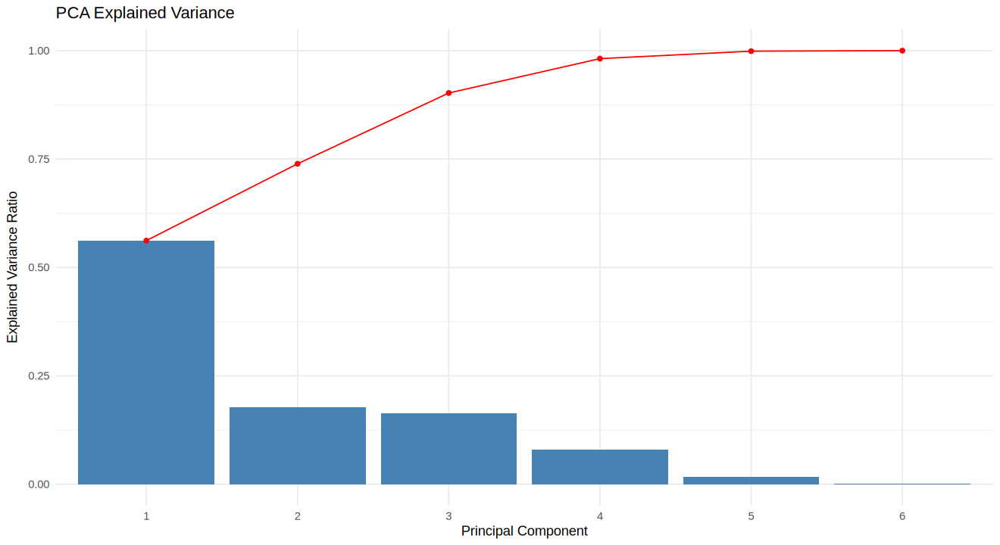

In [16]:
scree_df <- data.frame(PC = factor(seq_along(var_ratio)), Individual = var_ratio, Cumulative = cumsum(var_ratio))

ggplot(scree_df, aes(x = PC)) +
  geom_col(aes(y = Individual), fill = "steelblue") +
  geom_line(aes(y = Cumulative, group = 1), color = "red") +
  geom_point(aes(y = Cumulative), color = "red") +
  labs(title = "PCA Explained Variance", x = "Principal Component", y = "Explained Variance Ratio") +
  theme_minimal()

round(pca_full$rotation[, 1:2], 3)

## 17. Cluster-Wise Customer Profiling

  KMeans_Cluster Customers Recency Frequency Monetary AvgTransactionValue
1              1      1061  157.62      1.43   189.03              143.48
2              2      1165  128.99      1.58   732.73              507.69
3              3       790   20.66     12.92  7845.62              767.73
4              4      1322   51.13      3.75  1236.75              349.13
  TotalQuantity PurchaseFrequency UniqueProducts AvgBasketQuantity Customers_%
1        106.95              1.06          16.54             82.53       24.46
2        410.50              1.26          37.22            300.16       26.86
3       4518.88              1.57         149.88            474.39       18.21
4        749.16              0.50          66.16            214.20       30.47
  Revenue_%
1      2.26
2      9.61
3     69.74
4     18.40


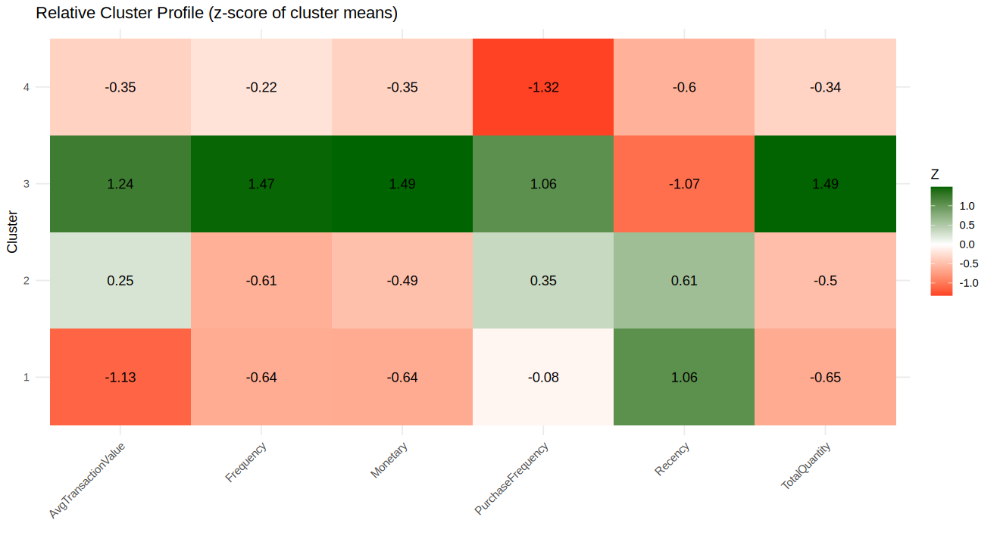

In [17]:
profile <- customer %>%
  group_by(KMeans_Cluster) %>%
  summarise(
    Customers = n(),
    Revenue = sum(Monetary),
    across(all_of(features), ~ round(mean(.x), 2)),
    .groups = "drop"
  ) %>%
  mutate(`Customers_%` = round(Customers / sum(Customers) * 100, 2),
         `Revenue_%` = round(Revenue / sum(Revenue) * 100, 2)) %>%
  dplyr::select(-Revenue)

print(as.data.frame(profile))

cluster_means_z <- customer %>%
  group_by(KMeans_Cluster) %>%
  summarise(across(all_of(cluster_features), mean), .groups = "drop")

z_matrix <- scale(as.matrix(cluster_means_z[cluster_features]))
z_df <- as.data.frame(z_matrix)
z_df$Cluster <- factor(cluster_means_z$KMeans_Cluster)

z_df %>%
  pivot_longer(-Cluster, names_to = "Feature", values_to = "Z") %>%
  ggplot(aes(x = Feature, y = Cluster, fill = Z)) +
  geom_tile() +
  geom_text(aes(label = round(Z, 2))) +
  scale_fill_gradient2(low = "red", mid = "white", high = "darkgreen") +
  labs(title = "Relative Cluster Profile (z-score of cluster means)", x = NULL, y = "Cluster") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

## 18. Segment Naming

In [18]:
overall <- c(Recency = mean(customer$Recency),
             Frequency = mean(customer$Frequency),
             Monetary = mean(customer$Monetary))

cluster_means <- customer %>%
  group_by(KMeans_Cluster) %>%
  summarise(Recency = mean(Recency), Frequency = mean(Frequency), Monetary = mean(Monetary), .groups = "drop") %>%
  as.data.frame()

name_segment <- function(r, f, m) {
  recent <- r < overall["Recency"]
  frequent <- f > overall["Frequency"]
  big_spender <- m > overall["Monetary"]
  if (recent && frequent && big_spender) return("Champions")
  if (frequent && big_spender) return("Loyal High Spenders At Risk")
  if (recent && frequent) return("Loyal Customers")
  if (recent) return("Recent Low-Value Customers")
  if (big_spender) return("Big Spenders Lapsing")
  "Dormant Customers"
}

cluster_means$Segment <- mapply(name_segment, cluster_means$Recency, cluster_means$Frequency,
                                cluster_means$Monetary, USE.NAMES = FALSE)
customer$Segment <- cluster_means$Segment[match(customer$KMeans_Cluster, cluster_means$KMeans_Cluster)]

cluster_means[, c("KMeans_Cluster", "Segment")]

KMeans_Cluster,Segment
<int>,<chr>
1,Dormant Customers
2,Dormant Customers
3,Champions
4,Recent Low-Value Customers


## 19. High-Value Segment Identification

In [19]:
z <- function(v) as.numeric(scale(v))

cluster_means$Score <- -z(cluster_means$Recency) + z(cluster_means$Frequency) + z(cluster_means$Monetary)

HIGH_VALUE_CLUSTER <- cluster_means$KMeans_Cluster[which.max(cluster_means$Score)]
HIGH_VALUE_SEGMENT <- cluster_means$Segment[which.max(cluster_means$Score)]
customer$HighValue <- as.integer(customer$KMeans_Cluster == HIGH_VALUE_CLUSTER)

cat("High-value cluster:", HIGH_VALUE_CLUSTER, "-", HIGH_VALUE_SEGMENT, "\n")
print(table(customer$HighValue))
print(round(prop.table(table(customer$HighValue)) * 100, 2))

High-value cluster: 3 - Champions 

   0    1 
3548  790 

    0     1 
81.79 18.21 


## 20. Train-Test Split

In [20]:
set.seed(SEED)

model_data <- customer_treated[features]
model_data$HighValue <- factor(customer$HighValue, levels = c(0, 1), labels = c("No", "Yes"))

idx_yes <- which(model_data$HighValue == "Yes")
idx_no <- which(model_data$HighValue == "No")

train_idx <- c(sample(idx_yes, floor(0.8 * length(idx_yes))),
               sample(idx_no, floor(0.8 * length(idx_no))))

train_df <- model_data[train_idx, ]
test_df <- model_data[-train_idx, ]

class_w <- c(No = 1, Yes = as.numeric(sum(train_df$HighValue == "No") / sum(train_df$HighValue == "Yes")))

cat("Train:", nrow(train_df), "Test:", nrow(test_df), "\n")
print(round(prop.table(table(train_df$HighValue)), 4))
print(round(prop.table(table(test_df$HighValue)), 4))

Train: 3470 Test: 868 

    No    Yes 
0.8179 0.1821 

   No   Yes 
0.818 0.182 


## 21. Evaluation Helper Functions

In [21]:
f1_score <- function(pred, truth) {
  tp <- sum(pred == "Yes" & truth == "Yes")
  fp <- sum(pred == "Yes" & truth == "No")
  fn <- sum(pred == "No" & truth == "Yes")
  if (tp == 0) return(0)
  2 * tp / (2 * tp + fp + fn)
}

class_metrics <- function(pred, truth, prob) {
  tp <- sum(pred == "Yes" & truth == "Yes")
  tn <- sum(pred == "No" & truth == "No")
  fp <- sum(pred == "Yes" & truth == "No")
  fn <- sum(pred == "No" & truth == "Yes")
  precision <- tp / (tp + fp)
  recall <- tp / (tp + fn)
  roc_obj <- roc(response = truth, predictor = prob, levels = c("No", "Yes"), direction = "<", quiet = TRUE)
  data.frame(
    Accuracy = (tp + tn) / length(truth),
    Precision = precision,
    Recall = recall,
    F1_Score = 2 * precision * recall / (precision + recall),
    ROC_AUC = as.numeric(auc(roc_obj))
  )
}

perm_importance <- function(pred_fun, data, feature_names, reps = 10) {
  base <- f1_score(pred_fun(data), data$HighValue)
  sapply(feature_names, function(f) {
    mean(replicate(reps, {
      d <- data
      d[[f]] <- sample(d[[f]])
      base - f1_score(pred_fun(d), d$HighValue)
    }))
  })
}

## 22. Random Forest Model

In [22]:
rf_grid <- expand.grid(mtry = c(2, 3, 4), nodesize = c(1, 3, 5))
rf_grid$OOB_F1 <- NA

for (i in seq_len(nrow(rf_grid))) {
  set.seed(SEED)
  fit <- randomForest(HighValue ~ ., data = train_df, ntree = 300,
                      mtry = rf_grid$mtry[i], nodesize = rf_grid$nodesize[i],
                      classwt = class_w)
  rf_grid$OOB_F1[i] <- f1_score(fit$predicted, train_df$HighValue)
}

best_rf <- rf_grid[which.max(rf_grid$OOB_F1), ]
print(rf_grid[order(-rf_grid$OOB_F1), ])

set.seed(SEED)
rf_model <- randomForest(HighValue ~ ., data = train_df, ntree = 500,
                         mtry = best_rf$mtry, nodesize = best_rf$nodesize,
                         classwt = class_w, importance = TRUE)

print(rf_model)

  mtry nodesize    OOB_F1
6    4        3 0.9512390
9    4        5 0.9504792
8    3        5 0.9482896
7    2        5 0.9466135
3    4        1 0.9458367
2    3        1 0.9448947
5    3        3 0.9446672
1    2        1 0.9421353
4    2        3 0.9420290

Call:
 randomForest(formula = HighValue ~ ., data = train_df, ntree = 500,      mtry = best_rf$mtry, nodesize = best_rf$nodesize, classwt = class_w,      importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 4

        OOB estimate of  error rate: 1.76%
Confusion matrix:
      No Yes class.error
No  2815  23 0.008104299
Yes   38 594 0.060126582


## 23. Support Vector Machine Model

In [23]:
set.seed(SEED)
svm_tune <- tune(
  svm, HighValue ~ ., data = train_df, kernel = "radial",
  ranges = list(cost = c(0.1, 1, 10), gamma = c(0.01, 0.1, 1)),
  class.weights = class_w,
  tunecontrol = tune.control(cross = 5)
)

print(svm_tune$performances)
print(svm_tune$best.parameters)

svm_model <- svm(
  HighValue ~ ., data = train_df, kernel = "radial",
  cost = svm_tune$best.parameters$cost,
  gamma = svm_tune$best.parameters$gamma,
  class.weights = class_w, probability = TRUE, scale = TRUE
)

print(svm_model)

  cost gamma      error  dispersion
1  0.1  0.01 0.05792507 0.005799600
2  1.0  0.01 0.03429395 0.005524579
3 10.0  0.01 0.02017291 0.006027810
4  0.1  0.10 0.03515850 0.005155200
5  1.0  0.10 0.01959654 0.005448896
6 10.0  0.10 0.01152738 0.002695719
7  0.1  1.00 0.02737752 0.007059048
8  1.0  1.00 0.02190202 0.002771669
9 10.0  1.00 0.01959654 0.004394222
  cost gamma
6   10   0.1

Call:
svm(formula = HighValue ~ ., data = train_df, kernel = "radial", 
    cost = svm_tune$best.parameters$cost, gamma = svm_tune$best.parameters$gamma, 
    class.weights = class_w, probability = TRUE, scale = TRUE)


Parameters:
   SVM-Type:  C-classification 
 SVM-Kernel:  radial 
       cost:  10 

Number of Support Vectors:  115



## 24. Model Performance Comparison

          Model Accuracy Precision Recall F1_Score ROC_AUC
1 Random Forest   0.9781    0.9664 0.9114   0.9381  0.9974
2           SVM   0.9942    1.0000 0.9684   0.9839  0.9998


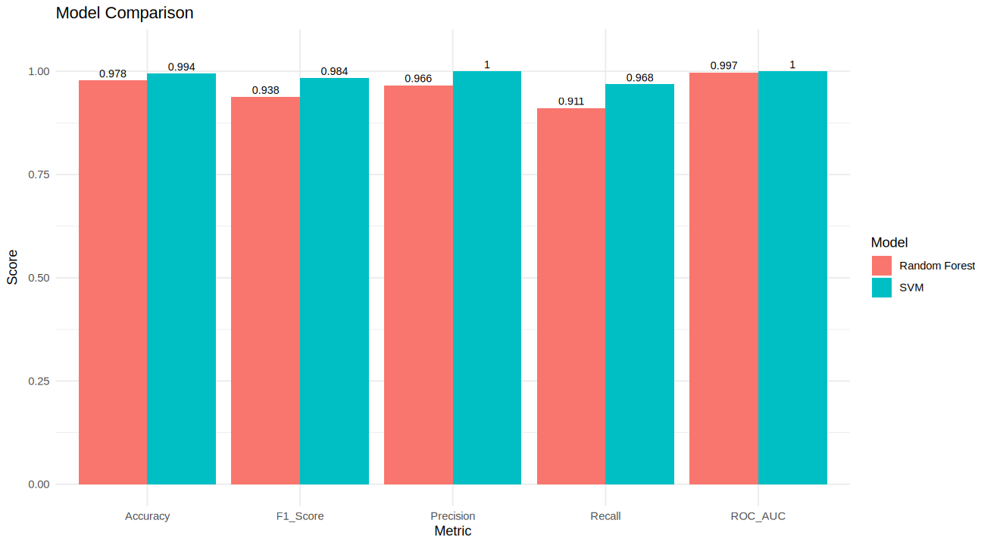

In [24]:
rf_pred <- predict(rf_model, test_df, type = "response")
rf_prob <- predict(rf_model, test_df, type = "prob")[, "Yes"]

svm_raw <- predict(svm_model, test_df, probability = TRUE)
svm_pred <- factor(as.character(svm_raw), levels = c("No", "Yes"))
svm_prob <- attr(svm_raw, "probabilities")[, "Yes"]

predictions <- list(
  "Random Forest" = list(pred = rf_pred, prob = rf_prob),
  "SVM" = list(pred = svm_pred, prob = svm_prob)
)

results_df <- do.call(rbind, lapply(names(predictions), function(n) {
  cbind(Model = n, class_metrics(predictions[[n]]$pred, test_df$HighValue, predictions[[n]]$prob))
}))
results_df[, -1] <- round(results_df[, -1], 4)

print(results_df)

results_df %>%
  pivot_longer(-Model, names_to = "Metric", values_to = "Score") %>%
  ggplot(aes(x = Metric, y = Score, fill = Model)) +
  geom_col(position = "dodge") +
  geom_text(aes(label = round(Score, 3)), position = position_dodge(width = 0.9), vjust = -0.4, size = 3) +
  coord_cartesian(ylim = c(0, 1.05)) +
  labs(title = "Model Comparison") +
  theme_minimal()

## 25. Confusion Matrices

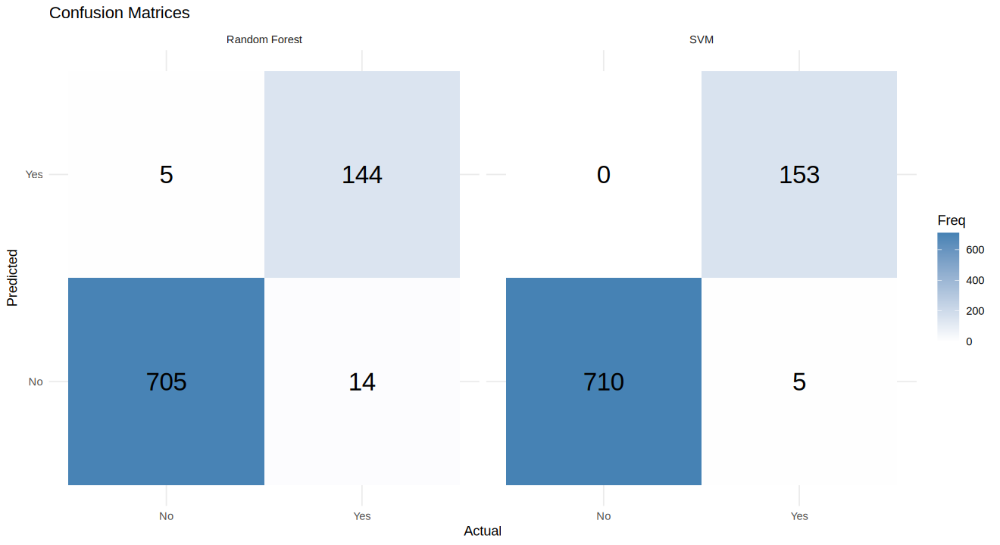

In [25]:
cm_df <- do.call(rbind, lapply(names(predictions), function(n) {
  tab <- as.data.frame(table(Predicted = predictions[[n]]$pred, Actual = test_df$HighValue))
  tab$Model <- n
  tab
}))

ggplot(cm_df, aes(x = Actual, y = Predicted, fill = Freq)) +
  geom_tile() +
  geom_text(aes(label = Freq), size = 7) +
  facet_wrap(~Model) +
  scale_fill_gradient(low = "white", high = "steelblue") +
  labs(title = "Confusion Matrices") +
  theme_minimal()

## 26. ROC Curves

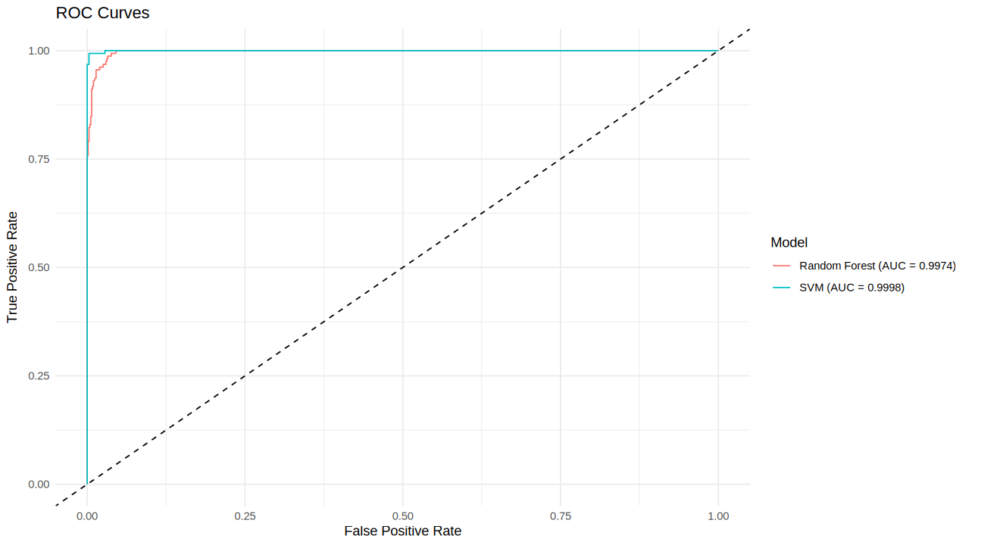

In [26]:
roc_list <- lapply(predictions, function(p) {
  roc(response = test_df$HighValue, predictor = p$prob, levels = c("No", "Yes"), direction = "<", quiet = TRUE)
})

names(roc_list) <- paste0(names(roc_list), " (AUC = ", sapply(roc_list, function(r) round(as.numeric(auc(r)), 4)), ")")

ggroc(roc_list, legacy.axes = TRUE) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  labs(title = "ROC Curves", x = "False Positive Rate", y = "True Positive Rate", color = "Model") +
  theme_minimal()

## 27. Feature Importance Analysis

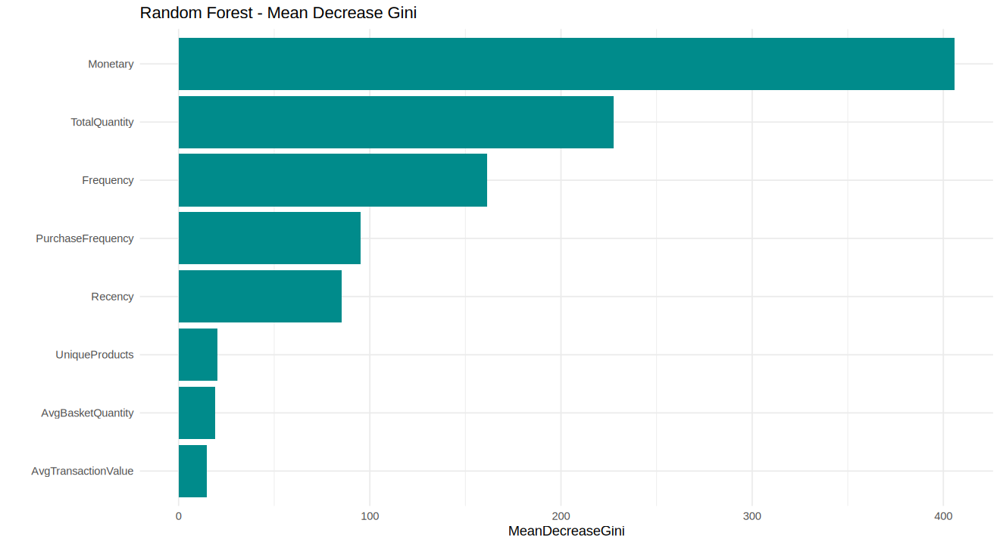

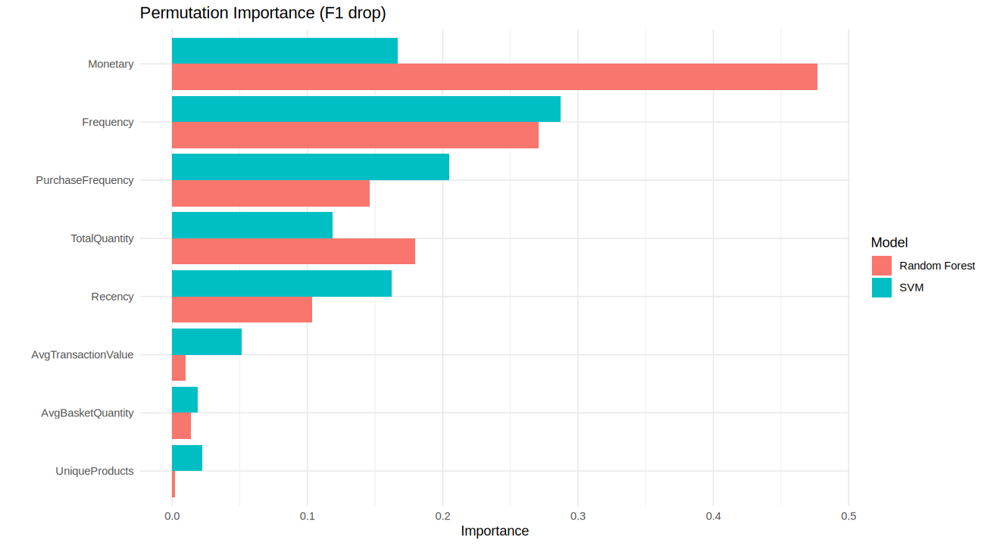

In [28]:
rf_imp <- as.data.frame(importance(rf_model))
rf_imp$Feature <- rownames(rf_imp)

p_gini <- ggplot(rf_imp, aes(x = reorder(Feature, MeanDecreaseGini), y = MeanDecreaseGini)) +
  geom_col(fill = "darkcyan") +
  coord_flip() +
  labs(title = "Random Forest - Mean Decrease Gini", x = NULL) +
  theme_minimal()

set.seed(SEED)
perm_rf <- perm_importance(function(d) predict(rf_model, d), test_df, features)
perm_svm <- perm_importance(function(d) factor(as.character(predict(svm_model, d)), levels = c("No", "Yes")), test_df, features)

perm_df <- rbind(
  data.frame(Feature = features, Importance = as.numeric(perm_rf), Model = "Random Forest"),
  data.frame(Feature = features, Importance = as.numeric(perm_svm), Model = "SVM")
)

p_perm <- ggplot(perm_df, aes(x = reorder(Feature, Importance), y = Importance, fill = Model)) +
  geom_col(position = "dodge") +
  coord_flip() +
  labs(title = "Permutation Importance (F1 drop)", x = NULL) +
  theme_minimal()

print(p_gini)
print(p_perm)

## 28. Interactive 3D Visualization of Customer Clusters (Plotly)

In [29]:
show_plotly <- function(fig, file) {
  saveWidget(fig, file, selfcontained = TRUE)
  tryCatch(
    IRdisplay::display_html(paste(readLines(file, warn = FALSE), collapse = "\n")),
    error = function(e) print(fig)
  )
}

plot3d_df <- data.frame(
  PC1 = pca_full$x[, 1],
  PC2 = pca_full$x[, 2],
  PC3 = pca_full$x[, 3],
  Segment = customer$Segment,
  Cluster = customer$KMeans_Cluster,
  Recency = customer$Recency,
  Frequency = customer$Frequency,
  Monetary = round(customer$Monetary, 2)
)
plot3d_df$Hover <- paste0("Cluster: ", plot3d_df$Cluster,
                          "<br>Recency: ", plot3d_df$Recency,
                          "<br>Frequency: ", plot3d_df$Frequency,
                          "<br>Monetary: ", plot3d_df$Monetary)

fig_pca3d <- plot_ly(
  plot3d_df, x = ~PC1, y = ~PC2, z = ~PC3, color = ~Segment, text = ~Hover,
  type = "scatter3d", mode = "markers", hoverinfo = "text",
  marker = list(size = 3, opacity = 0.75)
) %>%
  layout(title = paste0("3D Customer Clusters (Variance Explained: ",
                        round(sum(var_ratio[1:3]) * 100, 1), "%)"),
         legend = list(title = list(text = "Segment")))

show_plotly(fig_pca3d, "customer_clusters_pca_3d.html")

<!DOCTYPE html>
 
 
 
 plotly

## 29. Interactive 3D RFM Scatter (Plotly)

In [30]:
fig_rfm3d <- plot_ly(
  plot3d_df, x = ~Recency, y = ~Frequency, z = ~Monetary, color = ~Segment, text = ~Hover,
  type = "scatter3d", mode = "markers", hoverinfo = "text",
  marker = list(size = 3, opacity = 0.75)
) %>%
  layout(title = "3D RFM Customer Segments",
         scene = list(yaxis = list(type = "log"), zaxis = list(type = "log")))

show_plotly(fig_rfm3d, "customer_segments_rfm_3d.html")

<!DOCTYPE html>
 
 
 
 plotly

## 30. Segment-Wise Targeted Marketing Recommendations

In [31]:
strategies <- c(
  "Champions" = "Launch VIP loyalty tier, early access to new products, referral rewards, exclusive bundles, personalised thank-you offers.",
  "Loyal High Spenders At Risk" = "Send win-back campaign with personalised discounts, replenishment reminders, and a feedback survey before they lapse.",
  "Loyal Customers" = "Promote upsell and cross-sell bundles, tiered loyalty points, subscription offers, and product recommendations.",
  "Recent Low-Value Customers" = "Run onboarding email series, welcome discount on second purchase, free-shipping threshold nudges, and entry-level bundles.",
  "Big Spenders Lapsing" = "Trigger high-value reactivation offers, personal outreach, limited-time premium deals, and showcase new arrivals.",
  "Dormant Customers" = "Use low-cost reactivation emails, deep-discount clearance offers, and sunset the segment from paid campaigns if unresponsive."
)

recommendations <- customer %>%
  group_by(KMeans_Cluster, Segment) %>%
  summarise(
    Customers = n(),
    Revenue = sum(Monetary),
    Avg_Recency = round(mean(Recency), 2),
    Avg_Frequency = round(mean(Frequency), 2),
    Avg_Monetary = round(mean(Monetary), 2),
    .groups = "drop"
  ) %>%
  mutate(`Revenue_%` = round(Revenue / sum(Revenue) * 100, 2),
         Marketing_Strategy = unname(strategies[Segment])) %>%
  dplyr::select(-Revenue) %>%
  as.data.frame()

options(width = 250)
print(recommendations)

  KMeans_Cluster                    Segment Customers Avg_Recency Avg_Frequency Avg_Monetary Revenue_%                                                                                                            Marketing_Strategy
1              1          Dormant Customers      1061      157.62          1.43       189.03      2.26 Use low-cost reactivation emails, deep-discount clearance offers, and sunset the segment from paid campaigns if unresponsive.
2              2          Dormant Customers      1165      128.99          1.58       732.73      9.61 Use low-cost reactivation emails, deep-discount clearance offers, and sunset the segment from paid campaigns if unresponsive.
3              3                  Champions       790       20.66         12.92      7845.62     69.74    Launch VIP loyalty tier, early access to new products, referral rewards, exclusive bundles, personalised thank-you offers.
4              4 Recent Low-Value Customers      1322       51.13          3.75     

## 31. Final Summary

In [32]:
best_idx <- which.max(results_df$F1_Score)

summary_df <- data.frame(
  Metric = c("Customers Analysed", "Optimal k (Elbow)", "K-Means Silhouette", "Hierarchical Silhouette",
             "K-Means vs Hierarchical ARI", "High-Value Cluster", "High-Value Customers (%)",
             "Best Model (F1)", "Best F1-Score", "Best ROC-AUC"),
  Value = c(nrow(customer), OPTIMAL_K, round(kmeans_silhouette, 4), round(hier_silhouette, 4),
            round(ari, 4), paste(HIGH_VALUE_CLUSTER, "-", HIGH_VALUE_SEGMENT),
            round(mean(customer$HighValue) * 100, 2),
            results_df$Model[best_idx], results_df$F1_Score[best_idx], results_df$ROC_AUC[best_idx])
)

print(summary_df)

                        Metric         Value
1           Customers Analysed          4338
2            Optimal k (Elbow)             4
3           K-Means Silhouette        0.2672
4      Hierarchical Silhouette        0.2123
5  K-Means vs Hierarchical ARI        0.5141
6           High-Value Cluster 3 - Champions
7     High-Value Customers (%)         18.21
8              Best Model (F1)           SVM
9                Best F1-Score        0.9839
10                Best ROC-AUC        0.9998
